# Оценка стоимости облигации и процентного свопа (RUB, срок 2 года)
_Трусковская Д.Р._

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import requests
import io
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams['font.family'] = 'Times New Roman'

## Скачивание доп данных

In [4]:
#Common pricing helpers

def discount_factor(t, r):
    """Continuous-compounding discount factor for year fraction t."""
    return np.exp(-r * t)


def survival_probability(t, annual_pd):
    """Constant hazard transformed from annual PD."""
    hazard = -np.log(1.0 - annual_pd)
    return np.exp(-hazard * t)

In [5]:
def zero_rate_from_ois_table(t, df_ois_ruonia):
    """
    Interpolated zero rate z(t) from OIS table.

    df_ois_ruonia columns:
      - 'Годы' or 'Месяцы'
      - 'OIS RUB RUONIA mid' in percent (e.g., 13.58)

    Returns z(t) in decimals (e.g., 0.1358).
    """
    t = np.asarray(t, dtype=float)

    tbl = df_ois_ruonia.copy()

    #Convert tenor to years (12 months in a year)
    if 'Годы' not in tbl.columns:
        if 'Месяцы' not in tbl.columns:
            raise ValueError("df_ois_ruonia must contain 'Годы' or 'Месяцы'")
        tbl['Годы'] = tbl['Месяцы'] / 12.0

    if 'OIS RUB RUONIA mid' not in tbl.columns:
        raise ValueError("df_ois_ruonia must contain 'OIS RUB RUONIA mid'")

    tbl = tbl[['Годы', 'OIS RUB RUONIA mid']].dropna().sort_values('Годы')

    x = tbl['Годы'].to_numpy(dtype=float)
    y = tbl['OIS RUB RUONIA mid'].to_numpy(dtype=float) / 100.0  # % -> decimal

    #Linear interpolation: z(t)
    z_t = np.interp(t, x, y)
    return z_t


def discount_factor_from_ois_table(t, df_ois_ruonia):
    """
    Continuous-compounding discount factor P(0,t) from interpolated OIS curve.
    """
    z_t = zero_rate_from_ois_table(t, df_ois_ruonia)
    return discount_factor(np.asarray(t, dtype=float), z_t)

In [6]:
#Market data loader (RUONIA ON from CBR), with fallback

def get_latest_ruonia(default_rate=0.15):
    """
    Download latest RUONIA ON from CBR page.

    :default_rate: fallback annual rate (decimal, e.g. 0.15 = 15%)
    :return: (rate_decimal, source_date_or_None)
    """
    url = 'https://cbr.ru/hd_base/ruonia/dynamics/'
    to_date = dt.date.today().strftime('%d.%m.%Y')
    params = {
        'UniDbQuery.Posted': 'True',
        'UniDbQuery.From': '01.01.2024',
        'UniDbQuery.To': to_date,
    }

    headers = {  #часто помогает от 403/упрощённой страницы
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36',
        'Accept-Language': 'ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7',
    }

    resp = None  #чтобы в except можно было безопасно печатать
    try:
        resp = requests.get(url, params=params, headers=headers, timeout=15)
        resp.raise_for_status()

        #Диагностика: что реально скачалось
        print("RUONIA HTTP:", resp.status_code)
        print("RUONIA final URL:", resp.url)
        print("RUONIA response length:", len(resp.text))

        tables = pd.read_html(io.StringIO(resp.text), decimal=',', thousands=None)
        print("RUONIA tables found:", len(tables))

        # Пытаемся найти таблицу, где явно есть RUONIA в названии колонок
        tbl = None
        for t in tables:
            cols = [str(c).lower() for c in t.columns]
            if any('ruonia' in c for c in cols):
                tbl = t.copy()
                break

        #Если не нашли — берем первую
        if tbl is None:
            tbl = tables[0].copy()

        #In CBR table first column is date, second one is RUONIA rate.
        date_col = tbl.columns[0]
        rate_col = tbl.columns[1]

        tbl[date_col] = pd.to_datetime(tbl[date_col], dayfirst=True, errors='coerce')
        tbl[rate_col] = tbl[rate_col].astype(str).str.replace(',', '.', regex=False).astype(float) / 100.0

        #Если read_html съел запятую и получилось 1525 вместо 15.25,
        #то после /100 будет 15.25 (всё ещё > 1), значит делим ещё раз.
        tbl.loc[tbl[rate_col] > 1.0, rate_col] = tbl.loc[tbl[rate_col] > 1.0, rate_col] / 100.0

        last_row = tbl.dropna(subset=[date_col, rate_col]).sort_values(date_col).iloc[-1]
        return float(last_row[rate_col]), pd.Timestamp(last_row[date_col]).date()

    except Exception as e:
        print("RUONIA download failed:", repr(e))
        if resp is not None:
            print("RUONIA HTTP (failed):", resp.status_code)
            print("RUONIA final URL (failed):", resp.url)
            print("RUONIA snippet (failed):", resp.text[:300])
        return float(default_rate), None

In [7]:
#Market curve proxy (RUONIA ON)
ruonia_rate, ruonia_date = get_latest_ruonia(default_rate=0.15)
if ruonia_date is None:
    print(f'RUONIA download failed -> fallback used: {ruonia_rate:.2%}')
else:
    print(f'Latest RUONIA used: {ruonia_rate:.2%} (date: {ruonia_date})')

RUONIA HTTP: 200
RUONIA final URL: https://cbr.ru/hd_base/ruonia/dynamics/?UniDbQuery.Posted=True&UniDbQuery.From=01.01.2024&UniDbQuery.To=27.02.2026
RUONIA response length: 244817
RUONIA tables found: 1
Latest RUONIA used: 15.25% (date: 2026-02-26)


In [8]:
ruonia_rate

0.1525

In [9]:
df_ois_ruonia = pd.read_excel('OIS RUB RUONIA.xlsx')

In [10]:
#Интерполяция значения для 18 месяцев
x = df_ois_ruonia['Месяцы'].to_numpy(dtype=float)
y = df_ois_ruonia['OIS RUB RUONIA mid'].to_numpy(dtype=float)

rate_18m = float(np.interp(18.0, x, y))

#Добавляем строку
new_row = pd.DataFrame({'Месяцы': [18],'OIS RUB RUONIA mid': [rate_18m],'Ссылка': [None],})

df_ois_ruonia = pd.concat([df_ois_ruonia, new_row], ignore_index=True)
df_ois_ruonia = df_ois_ruonia.sort_values('Месяцы').reset_index(drop=True)

df_ois_ruonia

,Месяцы,OIS RUB RUONIA mid,Ссылка
0,3,14.900,https://cbonds.ru/indexes/62931/
1,6,14.800,https://cbonds.ru/indexes/62933/
2,9,14.750,https://cbonds.ru/indexes/72835/
3,12,14.750,https://cbonds.ru/indexes/62935/
4,18,14.165,None
5,24,13.580,https://cbonds.ru/indexes/62937/


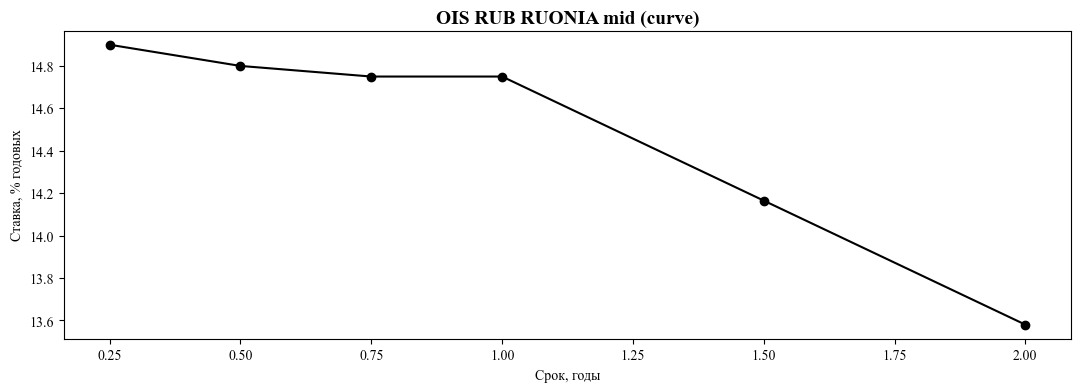

In [11]:
df_ois_ruonia['Годы'] = df_ois_ruonia['Месяцы'] / 12.0

plt.figure(figsize=(13, 4))
plt.plot(df_ois_ruonia['Годы'],df_ois_ruonia['OIS RUB RUONIA mid'],marker='o', color='black')
plt.title('OIS RUB RUONIA mid (curve)', fontdict={'fontweight': 'bold', 'fontsize': 14})
plt.xlabel('Срок, годы')
plt.ylabel('Ставка, % годовых')
plt.show()

## Часть 1: Bond valuation (2Y, RUB, default risk)

In [12]:
def price_bond_with_default(
    notional=1000.0,
    coupon_rate=0.10,
    maturity_years=2.0,
    payments_per_year=2,
    discount_rate=0.15,
    annual_pd=0.02,
    recovery_rate=0.0,
    df_ois_ruonia=None,
):
    """
    Price a fixed coupon bond under reduced-form default setup.

    :notional:          face value
    :coupon_rate:       annual coupon rate (decimal)
    :maturity_years:    time to maturity in years
    :payments_per_year: coupon frequency
    :discount_rate:     flat annual discount rate
    :annual_pd:         annual default probability
    :recovery_rate:     fraction of notional recovered upon default

    :return: (pv, schedule_dataframe)
    """
    dtau = 1.0 / payments_per_year
    n = int(round(maturity_years * payments_per_year))
    t = np.arange(1, n + 1) * dtau

    coupon = notional * coupon_rate / payments_per_year
    promised_cf = np.full(n, coupon)
    promised_cf[-1] += notional

    surv = survival_probability(t, annual_pd)
    surv_prev = np.r_[1.0, surv[:-1]]
    default_interval = surv_prev - surv

    recovery_cf = recovery_rate * notional * default_interval
    expected_cf = promised_cf * surv + recovery_cf

    if df_ois_ruonia is not None:
        df = discount_factor_from_ois_table(t, df_ois_ruonia)
    else:
        df = discount_factor(t, discount_rate)
    pv_cf = expected_cf * df

    schedule = pd.DataFrame({
        't_year': t,
        'promised_cf': promised_cf,
        'survival_prob': surv,
        'default_prob_interval': default_interval,
        'expected_cf': expected_cf,
        'discount_factor': df,
        'pv_cf': pv_cf,
    })

    return float(pv_cf.sum()), schedule

In [13]:
bond_pv, bond_schedule = price_bond_with_default(
    notional=1000.0,
    coupon_rate=0.10,
    maturity_years=2.0,
    payments_per_year=2,
    annual_pd=0.02,
    recovery_rate=0.0,
    df_ois_ruonia=df_ois_ruonia,
)

In [14]:
bond_pv

896.0458466549165

In [15]:
bond_schedule

,t_year,promised_cf,survival_prob,default_prob_interval,expected_cf,discount_factor,pv_cf
0,0.5,50.0,0.989949,0.010051,49.497475,0.928672,45.966904
1,1.0,50.0,0.980000,0.009949,49.000000,0.862862,42.280259
2,1.5,50.0,0.970151,0.009849,48.507525,0.808581,39.222240
3,2.0,1050.0,0.960400,0.009751,1008.420000,0.762159,768.576443


## Часть 2: Interest Rate Swap valuation (receive fixed, pay float)

In [16]:
def price_irs_receive_fixed(
    notional=1000.0,
    fixed_rate=0.15,
    maturity_years=2.0,
    payments_per_year=2,
    discount_rate=ruonia_rate,
    df_ois_ruonia=None,
):
    """
    Value an OIS-style IRS:
    receive fixed, pay floating (RUONIA ON), payments 'payments_per_year' times.

    Assumptions:
    - swap starts today (t0=0)
    - no notional exchange
    - single curve: discounting and forwarding from same curve
    """
    dtau = 1.0 / payments_per_year
    n = int(round(maturity_years * payments_per_year))
    t = np.arange(1, n + 1) * dtau

    #Discount factors
    if df_ois_ruonia is not None:
        df = discount_factor_from_ois_table(t, df_ois_ruonia)
    else:
        df = discount_factor(t, discount_rate)
    df_prev = np.r_[1.0, df[:-1]]  #P(0,t_{i-1}) with P(0,0)=1

    #Fixed leg cashflows
    fixed_coupon = notional * fixed_rate / payments_per_year  #N*K*dtau
    fixed_cf = np.full(n, fixed_coupon)
    pv_fixed_cf = fixed_cf * df
    pv_fixed_leg = pv_fixed_cf.sum()

    #Float leg cashflows via discount factors:
    #float_cf_i = N * (P(0,t_{i-1})/P(0,t_i) - 1)
    float_cf = notional * (df_prev / df - 1.0)
    pv_float_cf = float_cf * df
    pv_float_leg = pv_float_cf.sum()

    #Swap value for receive fixed / pay float
    npv = pv_fixed_leg - pv_float_leg

    #Par rate (useful check)
    annuity = np.sum(dtau * df)
    par_rate = (1.0 - df[-1]) / annuity

    schedule = pd.DataFrame({
        't_year': t,
        'discount_factor': df,
        'fixed_cf': fixed_cf,
        'pv_fixed_cf': pv_fixed_cf,
        'float_cf': float_cf,
        'pv_float_cf': pv_float_cf,
    })

    return float(npv), schedule, float(par_rate)

In [17]:
#IRS valuation (receive fixed 15%, pay RUONIA-linked float)
swap_npv, swap_schedule, par_rate = price_irs_receive_fixed(
    notional=1000.0,
    fixed_rate=0.15,
    maturity_years=2.0,
    payments_per_year=2,
    df_ois_ruonia=df_ois_ruonia,
)

#PV ножек считаем из schedule
pv_fixed = float(swap_schedule['pv_fixed_cf'].sum())
pv_float = float(swap_schedule['pv_float_cf'].sum())

In [18]:
swap_npv

14.329593237899672

In [19]:
swap_schedule

,t_year,discount_factor,fixed_cf,pv_fixed_cf,float_cf,pv_float_cf
0,0.5,0.928672,75.0,69.650377,76.806805,71.328306
1,1.0,0.862862,75.0,64.714683,76.268537,65.809256
2,1.5,0.808581,75.0,60.643540,67.132346,54.281908
3,2.0,0.762159,75.0,57.161930,60.907846,46.421467


In [20]:
par_rate

0.14147624827510058

In [21]:
#Final answer table
result = pd.DataFrame({
    'Instrument': [
        'Bond 2Y, coupon 10%, PD=2% annual',
        'IRS 2Y: receive fixed 15%, pay float RUONIA',
    ],
    'Current value, RUB': [bond_pv, swap_npv],
})

print('\nFinal valuation:')
print(result)


Final valuation:
                                    Instrument  Current value, RUB
0            Bond 2Y, coupon 10%, PD=2% annual          896.045847
1  IRS 2Y: receive fixed 15%, pay float RUONIA           14.329593


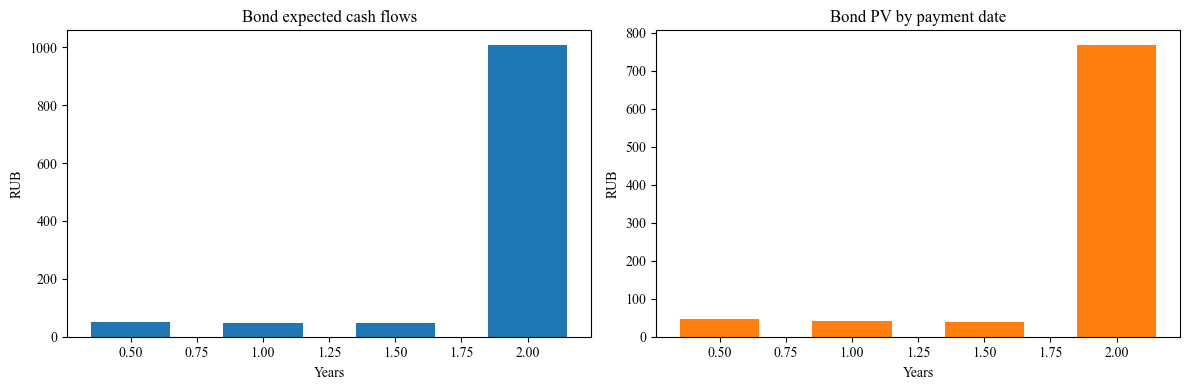

In [22]:
#Optional plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(bond_schedule['t_year'], bond_schedule['expected_cf'], width=0.3)
ax[0].set_title('Bond expected cash flows')
ax[0].set_xlabel('Years')
ax[0].set_ylabel('RUB')

ax[1].bar(bond_schedule['t_year'], bond_schedule['pv_cf'], width=0.3, color='tab:orange')
ax[1].set_title('Bond PV by payment date')
ax[1].set_xlabel('Years')
ax[1].set_ylabel('RUB')

plt.tight_layout()
plt.show()